# CaloryCal Pipeline

This notebook contains the end-to-end experimental workflow for **CaloryCal**, including:

- dataset loading and inspection
- FoodSeg103 mask visualisation
- class balance analysis
- conversion to YOLO segmentation format
- oversampling for rare classes
- YOLO segmentation training and validation
- depth estimation with Depth Anything V2
- per-item depth and area extraction
- calorie estimation and CSV export

> This notebook is the main research and prototyping notebook for the repository.


In [ ]:
# Install YOLO (Ultralytics)
!pip install ultralytics

# Install KaggleHub for dataset download
!pip install kagglehub

In [ ]:
!git clone https://github.com/DepthAnything/Depth-Anything-V2.git
%cd /content/Depth-Anything-V2
!pip install -r requirements.txt


# Load and prepare

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import kagglehub
import os
import sys
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import shutil
from tqdm import tqdm
from collections import defaultdict, Counter
import pandas as pd
import torch

from ultralytics import YOLO

In [ ]:
# Download dataset to train Yolo on segmenting food
path = kagglehub.dataset_download("ggrill/foodseg103")

print("Dataset downloaded to:", path)

# Check Dataset Structure

## Inspect sample files

In [ ]:
# Dataset paths
train_img_dir = os.path.join(path, "FoodSeg103", "Images", "img_dir", "train")
train_mask_dir = os.path.join(path, "FoodSeg103", "Images", "ann_dir", "train")

# Check paths
print("Train image dir:", train_img_dir)
print("Exists:", os.path.exists(train_img_dir))

print("Train mask dir:", train_mask_dir)
print("Exists:", os.path.exists(train_mask_dir))

# Pick the first training image
sample_img_name = sorted(os.listdir(train_img_dir))[0]

# Build matching mask name by replacing .jpg with .png
sample_mask_name = sample_img_name.replace(".jpg", ".png")

img_path = os.path.join(train_img_dir, sample_img_name)
mask_path = os.path.join(train_mask_dir, sample_mask_name)

# Load image and mask
image = np.array(Image.open(img_path))
mask = np.array(Image.open(mask_path))

# Print information
print("Image file:", sample_img_name)
print("Mask file:", sample_mask_name)
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask unique values:", np.unique(mask)[:50])


### Create colored mask

In [ ]:
num_classes = int(mask.max()) + 1
cmap = plt.cm.get_cmap("nipy_spectral", num_classes)

# Convert class IDs in the mask into RGB colours
colored_mask = cmap(mask)[:, :, :3]
colored_mask = (colored_mask * 255).astype(np.uint8)

### transparent mask in image

In [ ]:
alpha = 0.5  # transparency
overlay = image.copy()

# Only blend non-background pixels
foreground = mask > 0
overlay[foreground] = (
    (1 - alpha) * image[foreground] + alpha * colored_mask[foreground]
).astype(np.uint8)

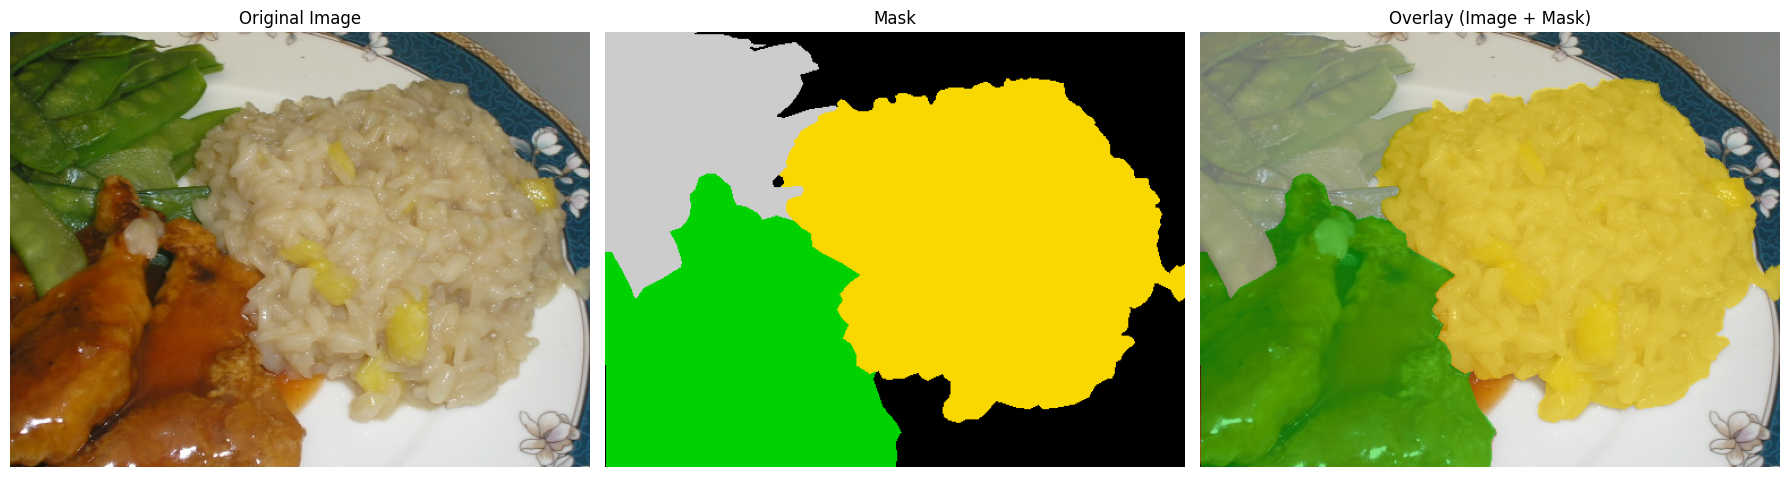

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="nipy_spectral")
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Overlay (Image + Mask)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Class Balance

In [ ]:
# Get all training mask files
mask_files = sorted(os.listdir(train_mask_dir))

print("Number of training masks:", len(mask_files))

In [ ]:
#Read label names from category_id.txt
category_file = os.path.join(path, "FoodSeg103", "category_id.txt")

label_map = {}

with open(category_file, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        # Handle either tab-separated or space-separated format
        if "\t" in line:
            parts = line.split("\t", 1)
        else:
            parts = line.split(maxsplit=1)

        if len(parts) == 2 and parts[0].isdigit():
            label_id = int(parts[0])
            label_name = parts[1].strip()
            label_map[label_id] = label_name

print("Number of labels found:", len(label_map))
print("First 10 labels:", list(label_map.items())[:10])

In [ ]:
# Count how many images contain each class

mask_files = sorted(os.listdir(train_mask_dir))
label_image_counts = Counter()

for mask_name in tqdm(mask_files, desc="Counting labels by image"):
    mask_path = os.path.join(train_mask_dir, mask_name)
    mask = np.array(Image.open(mask_path))

    # Get unique labels in this image, excluding background = 0
    labels_in_image = np.unique(mask)
    labels_in_image = labels_in_image[labels_in_image != 0]

    # Count each label once per image
    for label_id in labels_in_image:
        label_image_counts[int(label_id)] += 1

print("Number of labels appearing in train set:", len(label_image_counts))

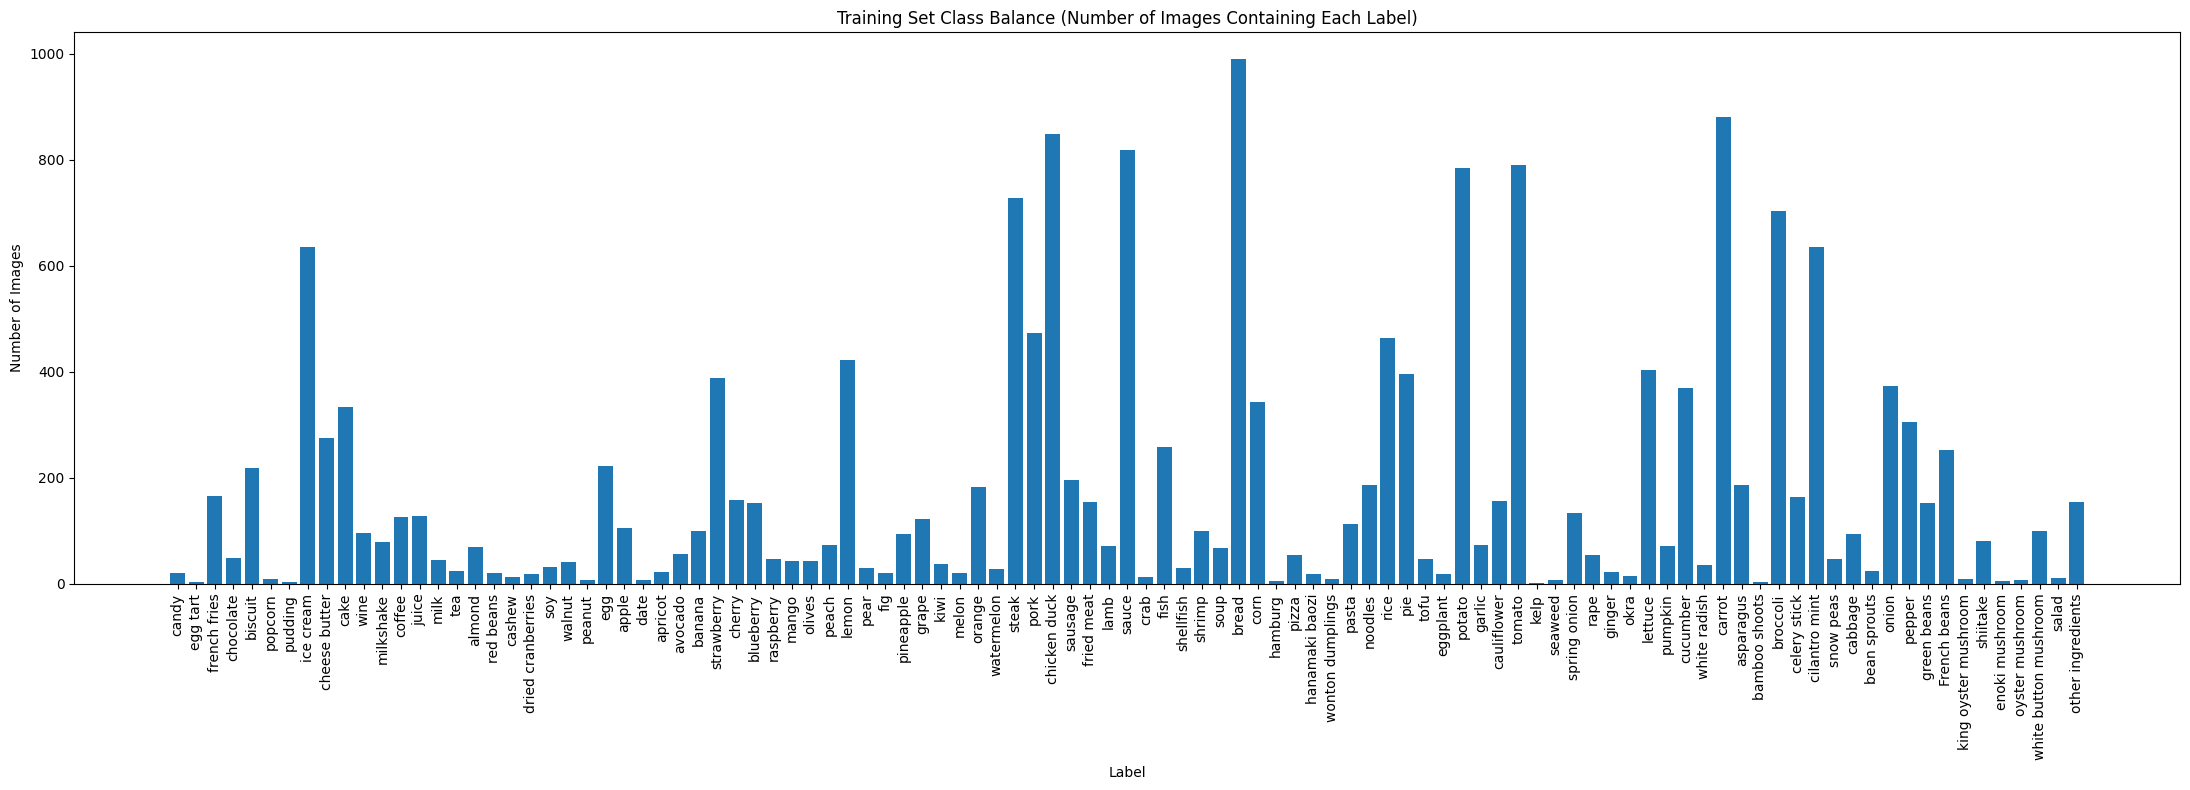

In [ ]:
sorted_label_ids = sorted(label_image_counts.keys())
x_labels = [label_map.get(label_id, f"Class {label_id}") for label_id in sorted_label_ids]
y_counts = [label_image_counts[label_id] for label_id in sorted_label_ids]

# Plot

plt.figure(figsize=(22, 8))
plt.bar(x_labels, y_counts)

plt.title("Training Set Class Balance (Number of Images Containing Each Label)")
plt.xlabel("Label")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Convert FoodSeg103 masks to YOLO segmentation labels

converting all classes except background 0 from FoodSeg103 into YOLO segmentation format by Build full class mapping: original FoodSeg103 ID -> YOLO ID excluding background 0

In [ ]:
all_original_ids = sorted([label_id for label_id in label_map.keys() if label_id != 0])

class_id_map = {orig_id: new_id for new_id, orig_id in enumerate(all_original_ids)}

print("Number of YOLO classes:", len(class_id_map))
print("Sample mapping:")
for i, (orig_id, yolo_id) in enumerate(class_id_map.items()):
    print(f"{orig_id} -> {yolo_id} ({label_map.get(orig_id, 'Unknown')})")
    if i >= 9:
        break

## Create YOLO output folders

In [ ]:
yolo_root = "/content/foodseg103_yolo_all"

images_train_out = os.path.join(yolo_root, "images", "train")
images_val_out   = os.path.join(yolo_root, "images", "val")
labels_train_out = os.path.join(yolo_root, "labels", "train")
labels_val_out   = os.path.join(yolo_root, "labels", "val")

for folder in [images_train_out, images_val_out, labels_train_out, labels_val_out]:
    os.makedirs(folder, exist_ok=True)

print("Created YOLO dataset folders under:", yolo_root)

## Convert one mask into YOLO polygons

This function:

*   loads one semantic mask
*   loops over every class present
*   extracts binary regions
*   finds contours
*   writes each contour as a YOLO polygon line

In [ ]:
def mask_to_yolo_segments(mask_path, class_id_map, min_area=10, epsilon_ratio=0.002):
    """
    Convert one semantic segmentation mask into YOLO segmentation label lines.

    Parameters
    ----------
    mask_path : str
        Path to the semantic mask PNG.
    class_id_map : dict
        Maps original FoodSeg103 IDs to YOLO class IDs.
    min_area : int
        Ignore tiny contours smaller than this area.
    epsilon_ratio : float
        Polygon simplification factor for cv2.approxPolyDP.

    Returns
    -------
    lines : list[str]
        YOLO segmentation lines, one line per object instance.
    """
    mask = np.array(Image.open(mask_path))
    h, w = mask.shape[:2]
    lines = []

    # Keep only class IDs that exist in this mask and are valid in the mapping
    present_ids = np.unique(mask)
    present_ids = [int(cid) for cid in present_ids if int(cid) in class_id_map]

    for original_class_id in present_ids:
        yolo_class_id = class_id_map[original_class_id]

        # Create binary mask for this class
        binary = (mask == original_class_id).astype(np.uint8) * 255

        # Find separate object regions
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            # Skip very small regions
            if cv2.contourArea(contour) < min_area:
                continue

            # Simplify contour slightly
            epsilon = epsilon_ratio * cv2.arcLength(contour, True)
            contour = cv2.approxPolyDP(contour, epsilon, True)

            contour = contour.squeeze(axis=1)

            # Need at least 3 points for a valid polygon
            if contour.ndim != 2 or contour.shape[0] < 3:
                continue

            # Normalise coordinates to [0, 1]
            polygon = []
            for x, y in contour:
                polygon.append(x / w)
                polygon.append(y / h)

            # YOLO segmentation format
            line = f"{yolo_class_id} " + " ".join(f"{p:.6f}" for p in polygon)
            lines.append(line)

    return lines


def convert_split_to_yolo(
    img_dir,
    mask_dir,
    out_img_dir,
    out_label_dir,
    class_id_map,
    min_area=10,
    epsilon_ratio=0.002
):
    """
    Convert all images in one split to YOLO segmentation format.
    """
    image_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(".jpg")])

    converted = 0
    missing_masks = 0
    empty_labels = 0

    for img_name in tqdm(image_files, desc=f"Converting {os.path.basename(img_dir)}"):
        mask_name = img_name.replace(".jpg", ".png")

        img_path = os.path.join(img_dir, img_name)
        mask_path = os.path.join(mask_dir, mask_name)

        # Skip if the matching mask does not exist
        if not os.path.exists(mask_path):
            missing_masks += 1
            continue

        # Convert mask to YOLO polygon lines
        lines = mask_to_yolo_segments(
            mask_path=mask_path,
            class_id_map=class_id_map,
            min_area=min_area,
            epsilon_ratio=epsilon_ratio
        )

        # Skip if no usable objects were found
        if len(lines) == 0:
            empty_labels += 1
            continue

        # Copy image
        shutil.copy(img_path, os.path.join(out_img_dir, img_name))

        # Save label file
        label_name = img_name.replace(".jpg", ".txt")
        label_path = os.path.join(out_label_dir, label_name)

        with open(label_path, "w", encoding="utf-8") as f:
            f.write("\n".join(lines))

        converted += 1

    print(f"\nFinished split: {os.path.basename(img_dir)}")
    print("Converted images :", converted)
    print("Missing masks    :", missing_masks)
    print("Empty labels     :", empty_labels)

## Convert train and test splits

In [ ]:
# Input folders

train_img_dir = os.path.join(path, "FoodSeg103", "Images", "img_dir", "train")
train_mask_dir = os.path.join(path, "FoodSeg103", "Images", "ann_dir", "train")

test_img_dir = os.path.join(path, "FoodSeg103", "Images", "img_dir", "test")
test_mask_dir = os.path.join(path, "FoodSeg103", "Images", "ann_dir", "test")


# Convert train -> train

convert_split_to_yolo(
    img_dir=train_img_dir,
    mask_dir=train_mask_dir,
    out_img_dir=images_train_out,
    out_label_dir=labels_train_out,
    class_id_map=class_id_map,
    min_area=10,
    epsilon_ratio=0.002
)


# Convert test -> val

convert_split_to_yolo(
    img_dir=test_img_dir,
    mask_dir=test_mask_dir,
    out_img_dir=images_val_out,
    out_label_dir=labels_val_out,
    class_id_map=class_id_map,
    min_area=10,
    epsilon_ratio=0.002
)

## Oversample rare classes in the TRAIN split only

In [ ]:
# Source dataset
src_root = yolo_root
src_train_img_dir = os.path.join(src_root, "images", "train")
src_train_lbl_dir = os.path.join(src_root, "labels", "train")
src_val_img_dir   = os.path.join(src_root, "images", "val")
src_val_lbl_dir   = os.path.join(src_root, "labels", "val")


# New oversampled dataset root
oversampled_root = "/content/foodseg103_yolo_all_oversampled"

os.makedirs(os.path.join(oversampled_root, "images", "train"), exist_ok=True)
os.makedirs(os.path.join(oversampled_root, "labels", "train"), exist_ok=True)
os.makedirs(os.path.join(oversampled_root, "images", "val"), exist_ok=True)
os.makedirs(os.path.join(oversampled_root, "labels", "val"), exist_ok=True)

# 1) Count how many TRAIN images contain each YOLO class (one count per image, not per polygon line)
train_label_files = sorted(
    [f for f in os.listdir(src_train_lbl_dir) if f.endswith(".txt")]
)

yolo_class_image_counts = Counter()
image_to_classes = {}

for lbl_name in tqdm(train_label_files, desc="Reading training labels"):
    lbl_path = os.path.join(src_train_lbl_dir, lbl_name)

    classes_in_image = set()

    with open(lbl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            class_id = int(parts[0])
            classes_in_image.add(class_id)

    image_to_classes[lbl_name] = classes_in_image

    for class_id in classes_in_image:
        yolo_class_image_counts[class_id] += 1

print("Number of YOLO classes found in training labels:", len(yolo_class_image_counts))

# 2) Define repeat factor based on the rarest class appearing in each image

def get_repeat_factor(class_count):
    """
    Repeat images containing very rare classes more often.
    """
    if class_count < 100:
        return 3
    elif class_count < 200:
        return 2
    else:
        return 1

# 3) Copy TRAIN images/labels into new oversampled dataset

new_train_img_dir = os.path.join(oversampled_root, "images", "train")
new_train_lbl_dir = os.path.join(oversampled_root, "labels", "train")

copied_original = 0
copied_augmented = 0

for lbl_name in tqdm(train_label_files, desc="Creating oversampled train split"):
    img_name_jpg = lbl_name.replace(".txt", ".jpg")
    img_name_png = lbl_name.replace(".txt", ".png")

    # Most of converted images are .jpg, but this keeps it safe.
    if os.path.exists(os.path.join(src_train_img_dir, img_name_jpg)):
        img_name = img_name_jpg
    elif os.path.exists(os.path.join(src_train_img_dir, img_name_png)):
        img_name = img_name_png
    else:
        print(f"Warning: no matching image found for {lbl_name}")
        continue

    src_img_path = os.path.join(src_train_img_dir, img_name)
    src_lbl_path = os.path.join(src_train_lbl_dir, lbl_name)

    classes_in_image = image_to_classes.get(lbl_name, set())

    if len(classes_in_image) == 0:
        repeat_factor = 1
    else:
        # Use the rarest class in this image to decide repetition
        rarest_count = min(yolo_class_image_counts[c] for c in classes_in_image)
        repeat_factor = get_repeat_factor(rarest_count)

    base_name = os.path.splitext(img_name)[0]
    img_ext = os.path.splitext(img_name)[1]

    for rep_idx in range(repeat_factor):
        if rep_idx == 0:
            # Keep original file name for the first copy
            new_img_name = img_name
            new_lbl_name = lbl_name
            copied_original += 1
        else:
            # Extra copies get a suffix
            new_img_name = f"{base_name}__rep{rep_idx}{img_ext}"
            new_lbl_name = f"{base_name}__rep{rep_idx}.txt"
            copied_augmented += 1

        dst_img_path = os.path.join(new_train_img_dir, new_img_name)
        dst_lbl_path = os.path.join(new_train_lbl_dir, new_lbl_name)

        shutil.copy(src_img_path, dst_img_path)
        shutil.copy(src_lbl_path, dst_lbl_path)

# 4) Copy VAL split unchanged

new_val_img_dir = os.path.join(oversampled_root, "images", "val")
new_val_lbl_dir = os.path.join(oversampled_root, "labels", "val")

val_images = sorted(os.listdir(src_val_img_dir))
val_labels = sorted(os.listdir(src_val_lbl_dir))

for name in tqdm(val_images, desc="Copying validation images"):
    shutil.copy(
        os.path.join(src_val_img_dir, name),
        os.path.join(new_val_img_dir, name)
    )

for name in tqdm(val_labels, desc="Copying validation labels"):
    shutil.copy(
        os.path.join(src_val_lbl_dir, name),
        os.path.join(new_val_lbl_dir, name)
    )

print("\nOversampling completed.")
print("Original training images copied :", copied_original)
print("Extra repeated training images  :", copied_augmented)
print("Total training images now       :", len(os.listdir(new_train_img_dir)))
print("Validation images copied        :", len(os.listdir(new_val_img_dir)))
print("New oversampled dataset root    :", oversampled_root)

## Create the YOLO YAML file

In [ ]:
yaml_path = os.path.join(oversampled_root, "foodseg103_all.yaml")

# YOLO names in 0..N-1 order
yolo_names = {new_id: label_map[orig_id] for orig_id, new_id in class_id_map.items()}

yaml_lines = [
    f"path: {oversampled_root}",
    "train: images/train",
    "val: images/val",
    "",
    "names:"
]

for class_id in sorted(yolo_names.keys()):
    yaml_lines.append(f"  {class_id}: {yolo_names[class_id]}")

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write("\n".join(yaml_lines))

print("Saved YAML file:", yaml_path)
print("Number of classes in YAML:", len(yolo_names))

## Save the class mapping for later (pipeline)

In [ ]:
mapping_txt = os.path.join(yolo_root, "class_mapping.txt")

with open(mapping_txt, "w", encoding="utf-8") as f:
    f.write("yolo_id\toriginal_foodseg103_id\tclass_name\n")
    for orig_id, yolo_id in sorted(class_id_map.items(), key=lambda x: x[1]):
        f.write(f"{yolo_id}\t{orig_id}\t{label_map.get(orig_id, 'Unknown')}\n")

print("Saved class mapping file:", mapping_txt)

# Train YOLO segmentation

In [ ]:
model = YOLO("yolo11m-seg.pt")   # changed from yolo11n-seg.pt to improve results

results = model.train(
    data=yaml_path,
    epochs=120,
    imgsz=768,    # increase image size from 512 to 640 to improve results
    batch=8,      # reduce batch to improve results
    patience=15,  # to stop training when validation stops improving
    cos_lr=True,  # smoother LR decay
    lr0=0.01,     # initial LR
    lrf=0.01,     # final LR fraction
    project="/content/drive/MyDrive/CaloryCal",
    name="foodseg103_allclasses_seg",
    save=True
)

In [ ]:
best_model_path = "/content/drive/MyDrive/CaloryCal/foodseg103_allclasses_seg/weights/best.pt" #path where the latest version of the trained model

In [ ]:
best_model = YOLO(best_model_path)
metrics = best_model.val( data="/content/foodseg103_yolo_all_oversampled/foodseg103_all.yaml")

## Validate best model explicitly

## Print key validation metrics clearly

In [ ]:
print("Box mAP50     :", metrics.box.map50)
print("Box mAP50-95  :", metrics.box.map)
print("Mask mAP50    :", metrics.seg.map50)
print("Mask mAP50-95 :", metrics.seg.map)

Box mAP50     : 0.3769721723466254
Box mAP50-95  : 0.31604516826755147
Mask mAP50    : 0.3785206162235533
Mask mAP50-95 : 0.30145476023174494


## Run prediction on one test image

In [ ]:
test_image_dir = "/content/foodseg103_yolo_all/images/val"
test_image_name = sorted(os.listdir(test_image_dir))[0]
test_image_path = os.path.join(test_image_dir, test_image_name)

results = best_model.predict(
    source=test_image_path,
    imgsz=768,
    conf=0.5,
    save=True,
    save_txt=False,
    show=False
)

print("Test image:", test_image_name)
print("Prediction completed.")

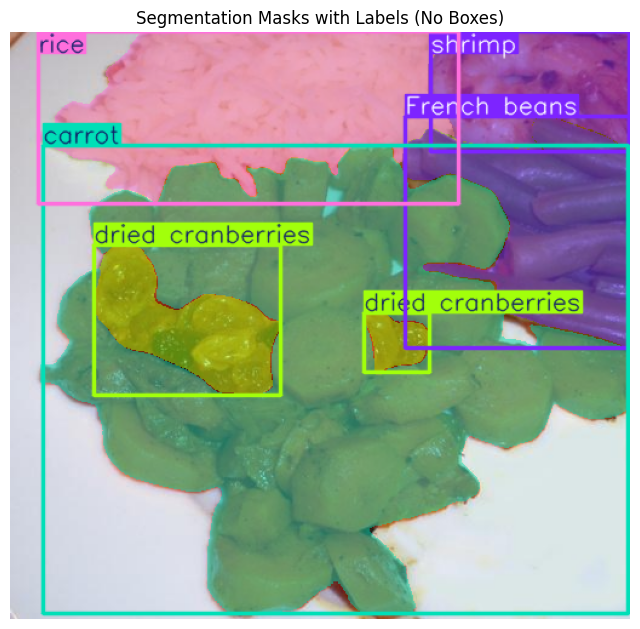

In [ ]:
# Get first result
result = results[0]

# Draw masks + labels (NO boxes, NO conf)
pred_img = result.plot(
    boxes=True,   # remove boxes
    labels=True,   # keep labels
    conf=False     # remove confidence
)

# Convert BGR → RGB
pred_img = pred_img[..., ::-1]

# Show result
plt.figure(figsize=(8, 8))
plt.imshow(pred_img)
plt.title("Segmentation Masks with Labels (No Boxes)")
plt.axis("off")
plt.show()

# Step 2: Depth using Depth Anything V2

## Install and load Depth Anything V2

In [ ]:
# Make Depth Anything V2 importable
sys.path.append("/content/Depth-Anything-V2")

from depth_anything_v2.dpt import DepthAnythingV2

# Choose encoder size: vits, vitb, vitl
encoder = "vitb"

model_configs = {
    "vits": {"encoder": "vits", "features": 64,  "out_channels": [48, 96, 192, 384]},
    "vitb": {"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]},
    "vitl": {"encoder": "vitl", "features": 256, "out_channels": [256, 512, 1024, 1024]},
}

depth_model = DepthAnythingV2(**model_configs[encoder])

# Download the matching checkpoint once
checkpoint_path = f"/content/depth_anything_v2_{encoder}.pth"
if not os.path.exists(checkpoint_path):
    !wget -O {checkpoint_path} https://huggingface.co/depth-anything/Depth-Anything-V2-Base/resolve/main/depth_anything_v2_vitb.pth

depth_model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
depth_model = depth_model.eval().cuda() if torch.cuda.is_available() else depth_model.eval()

## Run YOLO again with full-res masks

In [ ]:
results = best_model.predict(
    source=test_image_path,
    imgsz=768,
    conf=0.5,
    retina_masks=True,   # important: masks match original image size
    show=False
)

result = results[0]
print("Test image:", test_image_name)
print("Boxes present:", result.boxes is not None)
print("Masks present:", result.masks is not None)

## Create depth map for the same image

Image shape: (485, 512, 3)
Depth shape: (485, 512)
Depth min/max: 1.7075889 11.530785


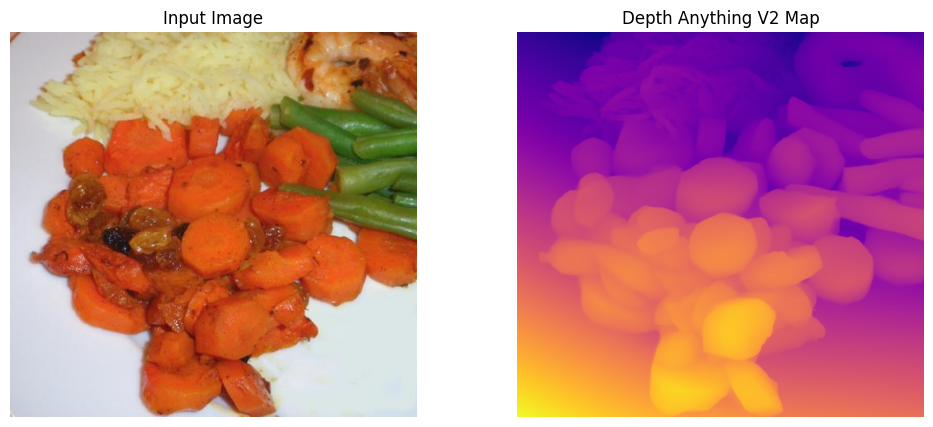

In [ ]:
image_bgr = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Depth Anything V2 inference
with torch.no_grad():
    depth = depth_model.infer_image(image_bgr)  # returns HxW relative depth map

depth = depth.astype(np.float32)

print("Image shape:", image_rgb.shape)
print("Depth shape:", depth.shape)
print("Depth min/max:", depth.min(), depth.max())

# Visualise depth map
depth_vis = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(depth_vis, cmap="plasma")
plt.title("Depth Anything V2 Map")
plt.axis("off")
plt.show()

## Extract depth for each segmented food item

In [ ]:
food_items = []

if result.masks is not None and result.boxes is not None:
    masks = result.masks.data.cpu().numpy()   # N x H x W
    classes = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    for i, mask in enumerate(masks):
        # Keep only predictions with confidence > 0.5
        if confs[i] <= 0.5:
            continue

        binary_mask = mask > 0.5

        if binary_mask.sum() == 0:
            continue

        masked_depth = depth[binary_mask]

        item = {
            "item_index": i,
            "class_id": int(classes[i]),
            "label": model.names[int(classes[i])],
            "confidence": float(confs[i]),
            "pixel_area": int(binary_mask.sum()),
            "depth_mean": float(masked_depth.mean()),
            "depth_median": float(np.median(masked_depth)),
            "depth_min": float(masked_depth.min()),
            "depth_max": float(masked_depth.max()),
        }
        food_items.append(item)

print("Detected food items:", len(food_items))
for item in food_items:
    print(item)

## visualise one image with masks + labels only and print depth per food item

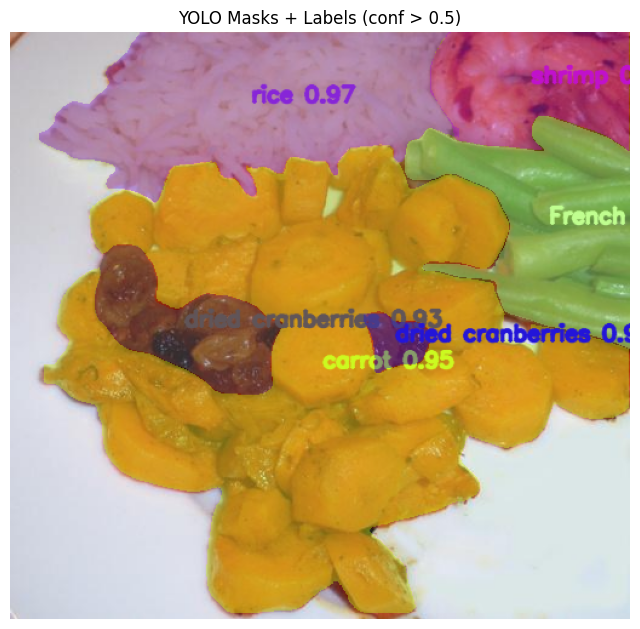

Per-food depth summary table:


,item_index,label,class_id,confidence,pixel_area,depth_mean,depth_median,depth_min,depth_max
0,0,rice,65,0.971,31781,3.7032,3.7913,1.7427,4.7308
1,1,carrot,83,0.945,98815,7.1222,7.1200,2.6672,10.6779
2,2,French beans,95,0.938,20287,5.0503,5.1985,2.8068,6.5302
3,3,dried cranberries,19,0.927,9915,7.4110,7.2968,4.7073,8.5788
4,4,dried cranberries,19,0.901,1775,6.9051,6.8617,5.1474,7.9697
5,5,shrimp,55,0.885,13583,3.6776,3.7300,2.0696,4.3404


In [ ]:
overlay = image_rgb.copy()
rng = np.random.default_rng(42)

if result.masks is not None:
    masks = result.masks.data.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int) if result.boxes is not None else np.zeros(len(masks), dtype=int)

    for i, mask in enumerate(masks):
        binary_mask = mask > 0.5
        if binary_mask.sum() == 0:
            continue

        color = rng.integers(0, 255, size=3, dtype=np.uint8)
        overlay[binary_mask] = (0.6 * overlay[binary_mask] + 0.4 * color).astype(np.uint8)

        ys, xs = np.where(binary_mask)
        x_center = int(xs.mean())
        y_center = int(ys.mean())

        label = model.names[int(classes[i])]
        overlay = image_rgb.copy()
rng = np.random.default_rng(42)

if result.masks is not None and result.boxes is not None:
    masks = result.masks.data.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    for i, mask in enumerate(masks):
        # Show only confident detections
        if confs[i] <= 0.5:
            continue

        binary_mask = mask > 0.5
        if binary_mask.sum() == 0:
            continue

        color = rng.integers(0, 255, size=3, dtype=np.uint8)
        overlay[binary_mask] = (0.6 * overlay[binary_mask] + 0.4 * color).astype(np.uint8)

        ys, xs = np.where(binary_mask)
        x_center = int(xs.mean())
        y_center = int(ys.mean())

        label = f"{model.names[int(classes[i])]} {confs[i]:.2f}"

        cv2.putText(
            overlay,
            label,
            (x_center, y_center),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color.tolist(),
            2,
            cv2.LINE_AA
        )

plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.title("YOLO Masks + Labels (conf > 0.5)")
plt.axis("off")
plt.show()


# Create depth summary table

df_food_items = pd.DataFrame(food_items)

# Reorder columns for readability
if not df_food_items.empty:
    df_food_items = df_food_items[
        [
            "item_index",
            "label",
            "class_id",
            "confidence",
            "pixel_area",
            "depth_mean",
            "depth_median",
            "depth_min",
            "depth_max",
        ]
    ]

    # Optional: round numeric columns
    df_food_items["confidence"] = df_food_items["confidence"].round(3)
    df_food_items["depth_mean"] = df_food_items["depth_mean"].round(4)
    df_food_items["depth_median"] = df_food_items["depth_median"].round(4)
    df_food_items["depth_min"] = df_food_items["depth_min"].round(4)
    df_food_items["depth_max"] = df_food_items["depth_max"].round(4)

    print("Per-food depth summary table:")
    display(df_food_items)
else:
    print("No food items detected.")

# Calorie Calculation

# Turn the per-item depth summary into a simple size estimate
Because Depth Anything V2 gives relative depth, not true centimetres, the right prototype move is to create a relative portion score from:

*   mask area in pixels
*   relative depth inside that mask



In [ ]:
df_food_items = pd.DataFrame(food_items)

if df_food_items.empty:
    print("No food items detected.")
else:

    # 1) Basic derived features

    # Relative thickness proxy from depth spread inside the item
    df_food_items["depth_range"] = df_food_items["depth_max"] - df_food_items["depth_min"]

    # Relative size score:
    # bigger mask area + stronger depth signal => larger portion
    # This is NOT real volume in cm^3, only a prototype score
    df_food_items["size_score"] = (
        df_food_items["pixel_area"] * df_food_items["depth_median"]
    )

    # Optional alternative using mean depth
    df_food_items["size_score_mean"] = (
        df_food_items["pixel_area"] * df_food_items["depth_mean"]
    )


    # 2) Normalise to make comparison easier

    max_size = df_food_items["size_score"].max()
    if max_size > 0:
        df_food_items["size_score_norm"] = df_food_items["size_score"] / max_size
    else:
        df_food_items["size_score_norm"] = 0.0

    # Portion category from normalised score
    def portion_label(x):
        if x < 0.33:
            return "small"
        elif x < 0.66:
            return "medium"
        else:
            return "large"

    df_food_items["portion_estimate"] = df_food_items["size_score_norm"].apply(portion_label)


    # 3) Select and format columns

    df_portion = df_food_items[
        [
            "item_index",
            "label",
            "confidence",
            "pixel_area",
            "depth_mean",
            "depth_median",
            "depth_range",
            "size_score",
            "size_score_norm",
            "portion_estimate",
        ]
    ].copy()

    # Round numeric columns for readability
    round_cols = ["confidence", "depth_mean", "depth_median", "depth_range", "size_score", "size_score_norm"]
    df_portion[round_cols] = df_portion[round_cols].round(4)

    # Sort from largest estimated portion to smallest
    df_portion = df_portion.sort_values("size_score", ascending=False).reset_index(drop=True)

    print("Per-food portion summary:")
    display(df_portion)

Per-food portion summary:


,item_index,label,confidence,pixel_area,depth_mean,depth_median,depth_range,size_score,size_score_norm,portion_estimate
0,1,carrot,0.9453,98815,7.1222,7.1200,8.0107,703565.6158,1.0000,large
1,0,rice,0.9705,31781,3.7032,3.7913,2.9881,120491.6102,0.1713,small
2,2,French beans,0.9375,20287,5.0503,5.1985,3.7233,105461.6921,0.1499,small
3,3,dried cranberries,0.9270,9915,7.4110,7.2968,3.8715,72347.2817,0.1028,small
4,5,shrimp,0.8849,13583,3.6776,3.7300,2.2708,50665.1473,0.0720,small
5,4,dried cranberries,0.9014,1775,6.9051,6.8617,2.8223,12179.5049,0.0173,small


In [ ]:
save_csv_path = "/content/drive/MyDrive/CaloryCal/one_image_portion_summary.csv"
df_portion.to_csv(save_csv_path, index=False)
print("Saved table to:", save_csv_path)

## estimate calories from label + portion score

In [ ]:
# Make sure df_portion already exists from STEP F
if df_portion.empty:
    print("No food items detected.")
else:
    # Simple calorie dictionary
    calorie_reference = {
        "rice": 206,
        "bread": 80,
        "tomato": 22,
        "carrot": 25,
        "broccoli": 55,
        "potato": 130,
        "cucumber": 16,
        "lettuce": 10,
        "onion": 44,
        "pepper": 24,
        "corn": 96,
        "sauce": 60,
        "fish": 180,
        "shrimp": 99,
        "steak": 250,
        "pork": 242,
        "chicken duck": 239,
        "fried meat": 280,
        "sausage": 301,
        "egg": 78,
        "pasta": 221,
        "noodles": 220,
        "pizza": 285,
        "pie": 320,
        "tofu": 144,
        "apple": 95,
        "banana": 105,
        "orange": 62,
        "grape": 62,
        "strawberry": 33,
        "blueberry": 57,
        "lemon": 17,
        "mango": 99,
        "avocado": 240,
        "watermelon": 46,
        "milk": 103,
        "coffee": 5,
        "juice": 110,
        "tea": 2,
        "ice cream": 137,
        "cake": 257,
        "chocolate": 230,
        "biscuit": 150,
        "french fries": 312,
        "hamburg": 295,
        "salad": 80,
        "soup": 90
    }

    # Add base calories by food label
    df_calories = df_portion.copy()
    df_calories["base_calories"] = df_calories["label"].map(calorie_reference)

    # Fill unknown foods with a default value
    default_calories = 100
    df_calories["base_calories"] = df_calories["base_calories"].fillna(default_calories)

    # ---------------------------------------------------
    # Convert relative size into a scaling factor
    #    small -> lower calories
    #    large -> higher calories
    # ---------------------------------------------------
    # Example scale:
    # 0.5 to 1.5 depending on relative portion size
    df_calories["portion_scale"] = 0.5 + df_calories["size_score_norm"]

    # Estimated calories
    df_calories["estimated_calories"] = (
        df_calories["base_calories"] * df_calories["portion_scale"]
    )

    # Round for readability
    df_calories["base_calories"] = df_calories["base_calories"].round(1)
    df_calories["portion_scale"] = df_calories["portion_scale"].round(2)
    df_calories["estimated_calories"] = df_calories["estimated_calories"].round(1)

    # Final calorie table
    df_calorie_table = df_calories[
        [
            "label",
            "confidence",
            "pixel_area",
            "depth_median",
            "size_score_norm",
            "portion_estimate",
            "base_calories",
            "portion_scale",
            "estimated_calories",
        ]
    ].copy()

    df_calorie_table = df_calorie_table.sort_values(
        "estimated_calories", ascending=False
    ).reset_index(drop=True)

    print("Per-food calorie estimate table:")
    display(df_calorie_table)

    # Total estimated calories for the image
    total_calories = df_calorie_table["estimated_calories"].sum().round(1)
    print(f"Total estimated calories for this image: {total_calories}")

Per-food calorie estimate table:


,label,confidence,pixel_area,depth_median,size_score_norm,portion_estimate,base_calories,portion_scale,estimated_calories
0,rice,0.9705,31781,3.7913,0.1713,small,206.0,0.67,138.3
1,French beans,0.9375,20287,5.1985,0.1499,small,100.0,0.65,65.0
2,dried cranberries,0.9270,9915,7.2968,0.1028,small,100.0,0.60,60.3
3,shrimp,0.8849,13583,3.7300,0.0720,small,99.0,0.57,56.6
4,dried cranberries,0.9014,1775,6.8617,0.0173,small,100.0,0.52,51.7
5,carrot,0.9453,98815,7.1200,1.0000,large,25.0,1.50,37.5


Total estimated calories for this image: 409.4


In [ ]:
save_csv_path = "/content/drive/MyDrive/CaloryCal/one_image_calorie_estimate.csv"
df_calorie_table.to_csv(save_csv_path, index=False)
print("Saved calorie table to:", save_csv_path)